In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import smarts_cerebellum.globals as gl

In [ ]:
df = pd.read_csv(f'{gl.baseDir}/Regression/MNISymC_slope_CST_df.tsv', sep = '\t') # slope for each subject at L/R CST
df['segment'] = df['image_name'].astype(str).str.split('_', n=4).str[3]

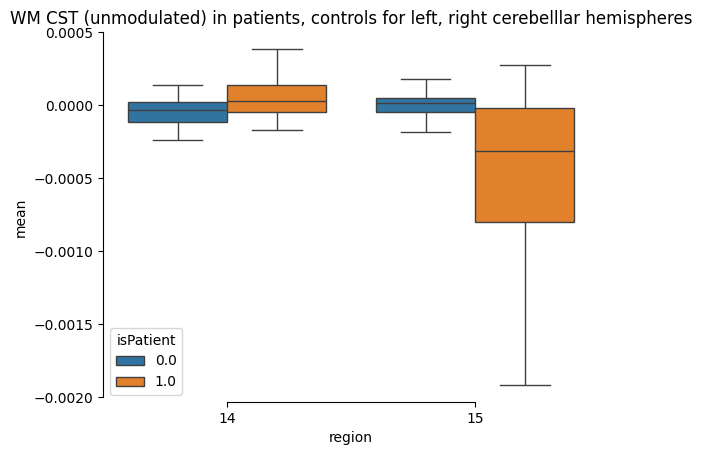

In [3]:
sns.boxplot(data = df[df.segment == 'WM'], x = 'region', y = 'mean', hue = 'isPatient', showfliers = False)

plt.title("WM CST (unmodulated) in patients, controls for left, right cerebelllar hemispheres")
sns.despine(trim = True)
plt.show()

In [4]:
# left cst = 14; right cst = 15

patients_wm_l = np.array(df[(df.segment == 'WM') & (df.isPatient == 1) & (df.region == 14)]['mean'])
patients_wm_r = np.array(df[(df.segment == 'WM') & (df.isPatient == 1) & (df.region == 15)]['mean'])

controls_wm_l = np.array(df[(df.segment == 'WM') & (df.isPatient == 0) & (df.region == 14)]['mean'])
controls_wm_r = np.array(df[(df.segment == 'WM') & (df.isPatient == 0) & (df.region == 15)]['mean'])

In [5]:
# independent t-test between patients and controls for each side (wm)
t_val_wm_l, p_val_wm_l = stats.ttest_ind(patients_wm_l, controls_wm_l)
print(f'**Independent t-test between patients, controls: WM CST, left (contralesional)** \n t-value: {t_val_wm_l}, p-value: {p_val_wm_l}')
print('\n')

t_val_wm_r, p_val_wm_r = stats.ttest_ind(patients_wm_r, controls_wm_r)
print(f'**Independent t-test between patients, controls: WM CST, right (ipsilesional)** \n t-value: {t_val_wm_r}, p-value: {p_val_wm_r}')

**Independent t-test between patients, controls: WM CST, left (contralesional)** 
 t-value: -1.5151337189827934, p-value: 0.13643553054164514


**Independent t-test between patients, controls: WM CST, right (ipsilesional)** 
 t-value: -2.7279603251618236, p-value: 0.008933603015748066


In [9]:
# paired t-test within patients for each side (wm)
t_val_wm_patients, p_val_wm_patients = stats.ttest_rel(patients_wm_l, patients_wm_r)
print(f'**Independent t-test within patients: WM CST** \n t-value: {t_val_wm_patients}, p-value: {p_val_wm_patients}')
print('\n')

**Independent t-test within patients: WM CST** 
 t-value: 3.983269191913481, p-value: 0.0003165631036364566


